Hikyuu 交互式工具示例
==============

1、引入交互式工具
-----------------
需从hikyuu.interactive引入，而不是直接从hikyuu库中引入（hikyuu是一个库，可用于编制其他的工具，而hikyuu.interactive是基于hikyuu库实现的交互式探索工具）

In [1]:
#%matplotlib inline
%time from hikyuu.interactive import *
#use_draw_engine('echarts') #use_draw_engine('matplotlib')  #默认为'matplotlib'绘图

2026-03-06 22:16:33,808 [INFO] runing in interactive session [<module>] (c:\Users\tt\AppData\Local\Programs\Python\Python313\Lib\site-packages\hikyuu\__init__.py:145) [hikyuu::hku_info]
2026-03-06 22:16:33,810 [INFO] running in jupyter [<module>] (c:\Users\tt\AppData\Local\Programs\Python\Python313\Lib\site-packages\hikyuu\__init__.py:152) [hikyuu::hku_info]


2026-03-06 22:16:33.814 [HKU-I] - 插件路径: c:\Users\tt\AppData\Local\Programs\Python\Python313\Lib\site-packages\hikyuu\plugin (StockManager.cpp:109)
2026-03-06 22:16:38.114 [HKU-I] - Using SQLITE3 BaseInfoDriver (BaseInfoDriver.cpp:56)
2026-03-06 22:16:38.118 [HKU-I] - 加载市场信息…… (StockManager.cpp:776)
2026-03-06 22:16:38.118 [HKU-I] - 加载证券类型信息…… (StockManager.cpp:793)
2026-03-06 22:16:38.119 [HKU-I] - 加载证券信息…… (StockManager.cpp:674)
2026-03-06 22:16:40.098 [HKU-I] - 加载权息数据…… (StockManager.cpp:810)
2026-03-06 22:16:40.201 [HKU-I] - 加载板块信息…… (StockManager.cpp:183)
2026-03-06 22:16:40.291 [HKU-I] - 加载K线数据…… (StockManager.cpp:187)
2026-03-06 22:16:40.292 [HKU-I] - 预加载 day K线数据至缓存 (最大数量: 100000)! (StockManager.cpp:238)
2026-03-06 22:16:40.293 [HKU-I] - 2.18 秒数据加载完毕. (StockManager.cpp:194)
CPU times: total: 1.02 s
Wall time: 8.64 s


2、创建交易系统并运行
--------------------

In [2]:
#创建模拟交易账户进行回测，初始资金30万
my_tm = crtTM(init_cash = 300000)

#创建信号指示器（以5日EMA为快线，5日EMA自身的10日EMA作为慢线，快线向上穿越慢线时买入，反之卖出）
my_sg = SG_Flex(EMA(C, n=5), slow_n=10)

#固定每次买入1000股
my_mm = MM_FixedCount(1000)

#创建交易系统并运行
sys = SYS_Simple(tm = my_tm, sg = my_sg, mm = my_mm)
sys.run(sm['sz000001'], Query(-150))

3、绘制曲线观察
---------------

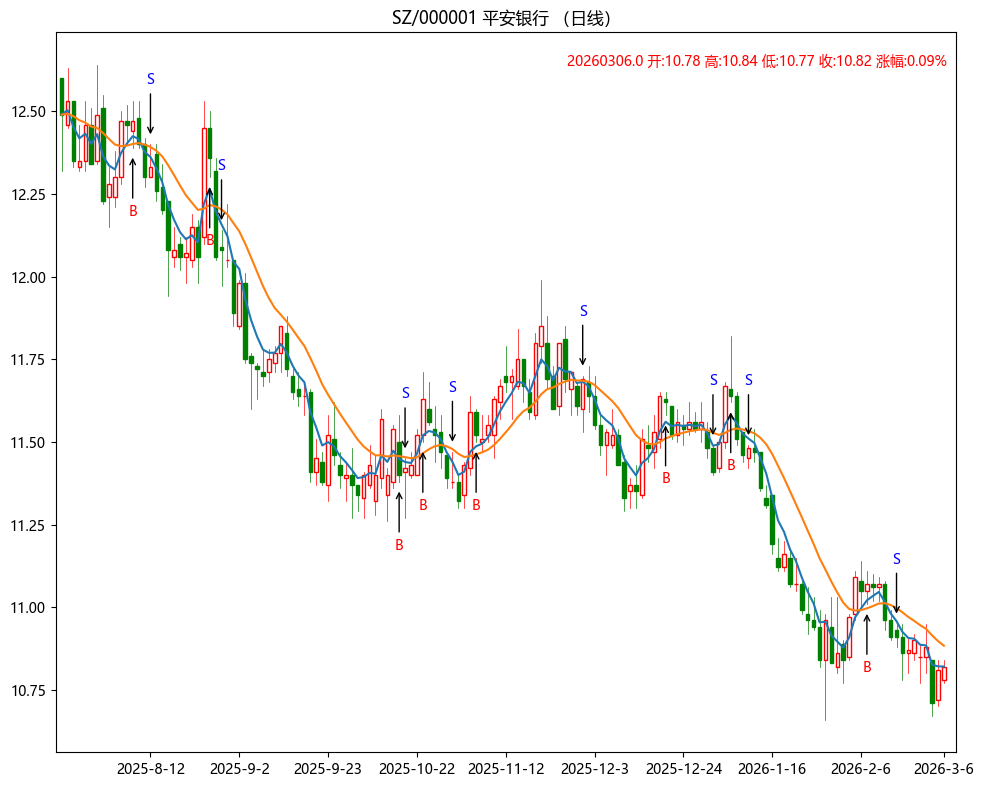

In [3]:
#绘制系统信号
sys.plot()

k = sm['sz000001'].get_kdata(Query(-150))
c = CLOSE(k)
fast = EMA(c, 5)
slow = EMA(fast, 10)

#绘制信号指示器使用两个指标
fast.plot(new=False)
slow.plot(new=False)

4、绘制资金收益曲线
---------------------

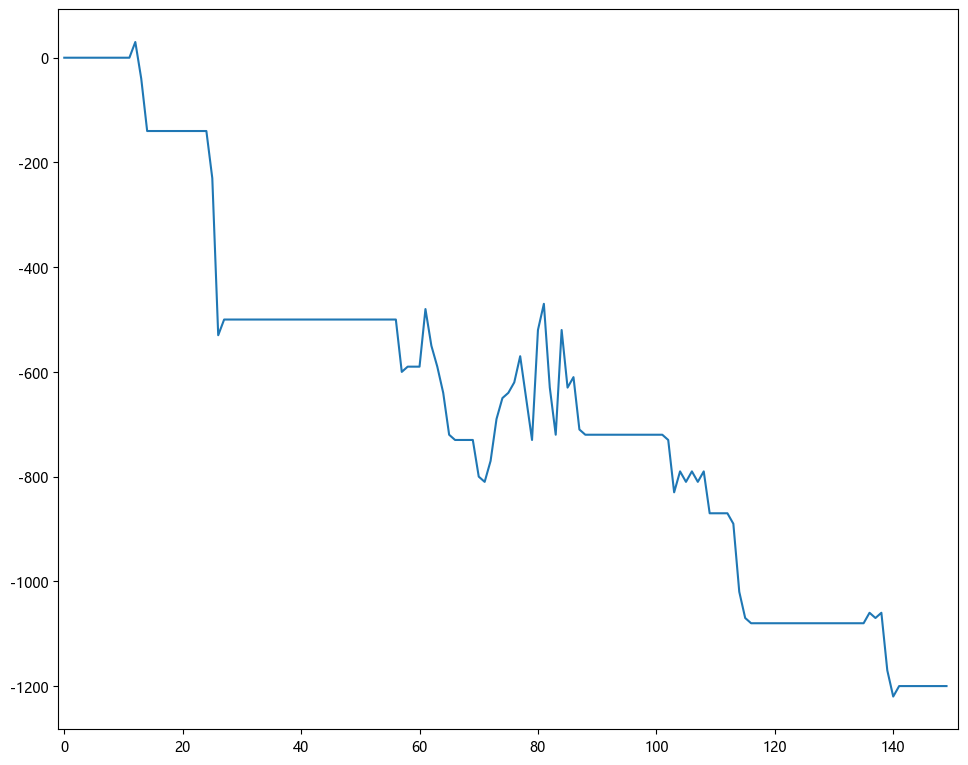

In [4]:
#绘制资金收益曲线
x = my_tm.get_profit_curve(k.get_datetime_list(), Query.DAY)
x = PRICELIST(x)
x.plot()

5、回测统计报告
----------------------

In [5]:
#回测统计
from datetime import datetime

per = my_tm.get_performance()
print(per.to_df())


                         name          value
0                帐户初始金额  300000.000000
1                累计投入本金  300000.000000
2                累计投入资产       0.000000
3                累计借入现金       0.000000
4                累计借入资产       0.000000
5                    累计红利       0.000000
6                    现金余额  298800.000000
7              未平仓头寸净值       0.000000
8                  当前总资产  298800.000000
9            已平仓交易总成本       0.000000
10           已平仓净利润总额   -1200.000000
11  单笔交易最大占用现金比例%       4.151938
12      交易平均占用现金比例%       3.917408
13          未平仓帐户收益率%      -0.400000
14          已平仓帐户收益率%      -0.400000
15          帐户年复合收益率%      -0.687685
16          帐户平均年收益率%      -0.688679
17           赢利交易赢利总额      10.000000
18           亏损交易亏损总额   -1210.000000
19             已平仓交易总数       8.000000
20                 赢利交易数       1.000000
21                 亏损交易数       7.000000
22              赢利交易比例%      12.500000
23                 赢利期望值    -150.002500
24           赢利交易平均赢利      10.000000
25

6、关于性能
---------------

经常有人问到性能问题，下面这段的代码使用之前的系统示例，遍历指定板块的所有股票，计算他们的“盈利交易比例%”（即胜率）。

In [6]:
def test_func(stock, query):
    """计算指定stock的系统策略胜率，系统策略为之前的简单双均线交叉系统（每次固定买入100股）
    """
    #创建模拟交易账户进行回测，初始资金30万
    my_tm = crtTM(init_cash = 1000000)

    #创建信号指示器（以5日EMA为快线，5日EMA自身的10日EMA作为慢线，快线向上穿越慢线时买入，反之卖出）
    my_sg = SG_Flex(EMA(C, n=5), slow_n=10)

    #固定每次买入1000股
    my_mm = MM_FixedCount(100)

    #创建交易系统并运行
    sys = SYS_Simple(tm = my_tm, sg = my_sg, mm = my_mm)
    sys.run(stock, query)
    
    per = my_tm.get_performance(ext=False)
    return per["赢利交易比例%"]

def total_func(blk, query):
    """遍历指定板块的所有的股票，计算系统胜率"""
    result = {}
    for s in blk:
        if s.valid and s.type != constant.STOCKTYPE_INDEX:
            result[s.name] = test_func(s, query)
    return result

遍历所有当前有效且并非指数的证券。下面是我的机器执行结果，共计算4151支证券，最近500个交易日，共耗时2.89秒。机器配置：Intel i7-4700HQ 2.G。

In [7]:
# 等待数据全部加载完毕后，测试后续实际计算性能（实际使用时不需要等，否则测试时间包含首次数据加载时间）
import time
while not sm.data_ready:
    time.sleep(0.5)

In [8]:
%time a = total_func(blocka, Query(-500))
print(f"计算证券数量: {len(a)}")

CPU times: total: 1.02 s
Wall time: 2.16 s
计算证券数量: 3491


In [9]:
# 10年 7000+ 支股票，vectorBT 的5~10倍速
%time a = total_func(blocka, Query(Datetime(20150101), Datetime(20260101)))
print(f"计算证券数量: {len(a)}")

CPU times: total: 3.58 s
Wall time: 7.76 s
计算证券数量: 3491
